# 📊 Evaluate Predictions — Interactive Browser

This notebook lets you:
1. Load a saved predictions file from `exp/inference/devset/`
2. Compute aggregate metrics (NDCG@1/10/20, Hit rates, Catalog Diversity)
3. **Interactively browse** any session and turn — see conversation, predicted tracks, ground truth, and scores

**Prerequisite:** Run inference first to generate a predictions file:
```bash
python run_inference_devset.py --tid llama1b_bm25_devset --batch_size 16
```

> For a Streamlit web UI version, run: `streamlit run streamlit_app.py`

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import os, json, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from datasets import load_dataset

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.dpi"] = 110
print("Ready!")

Ready!


---
## Configure: which predictions file to load

In [2]:
available = sorted(glob.glob("../exp/inference/devset/*.json"))
if available:
    print("Available prediction files:")
    for f in available:
        print(f"  {f}  ({os.path.getsize(f)//1024} KB)")
    PREDICTIONS_FILE = available[0]
    print(f"\nUsing: {PREDICTIONS_FILE}")
else:
    raise FileNotFoundError(
        "No prediction files found in ../exp/inference/devset/\n"
        "Run: python run_inference_devset.py --tid llama1b_bm25_devset"
    )

Available prediction files:
  ../exp/inference/devset/sample_bm25.json  (38 KB)

Using: ../exp/inference/devset/sample_bm25.json


---
## Load data

In [3]:
with open(PREDICTIONS_FILE) as f:
    raw_predictions = json.load(f)
predictions = {(p["session_id"], p["turn_number"]): p for p in raw_predictions}
print(f"Loaded {len(raw_predictions):,} predictions  ({len(predictions):,} unique session/turn pairs)")

Loaded 40 predictions  (40 unique session/turn pairs)


In [4]:
print("Loading ground truth (dev set)...")
conv_test = load_dataset("talkpl-ai/TalkPlayData-Challenge-Dataset", split="test")
sessions_dict = {s["session_id"]: s for s in conv_test}
ground_truth = {
    (s["session_id"], t["turn_number"]): t["content"]
    for s in conv_test
    for t in s["conversations"]
    if t["role"] == "music"
}
print(f"Sessions: {len(sessions_dict):,}  |  Ground truth entries: {len(ground_truth):,}")

Loading ground truth (dev set)...


Sessions: 1,000  |  Ground truth entries: 8,000


In [5]:
print("Loading track catalog...")
tracks_ds = load_dataset("talkpl-ai/TalkPlayData-Challenge-Track-Metadata", split="all_tracks")
track_meta = {item["track_id"]: item for item in tracks_ds}
print(f"Catalog: {len(track_meta):,} tracks")

Loading track catalog...


Catalog: 47,071 tracks


---
## Helper functions

In [6]:
def ndcg_at_k(predicted_ids, gt_id, k):
    if not gt_id or not predicted_ids:
        return 0.0
    for rank, tid in enumerate(predicted_ids[:k], start=1):
        if tid == gt_id:
            return 1.0 / math.log2(rank + 1)
    return 0.0

def hit_at_k(predicted_ids, gt_id, k):
    if not gt_id or not predicted_ids:
        return 0
    return int(gt_id in predicted_ids[:k])

def get_track_info(tid):
    meta = track_meta.get(tid, {})
    return {
        "name":   (meta.get("track_name")  or ["?"])[0],
        "artist": (meta.get("artist_name") or ["?"])[0],
        "album":  (meta.get("album_name")  or ["?"])[0],
        "tags":   ", ".join((meta.get("tag_list") or [])[:5]),
        "pop":    meta.get("popularity", "?"),
        "year":   str(meta.get("release_date", ""))[:4],
    }

def track_card_html(tid, rank=None, highlight=False):
    info = get_track_info(tid)
    bg     = "rgba(202,138,4,0.15)"  if highlight else "rgba(128,128,128,0.07)"
    border = "1px solid rgba(202,138,4,0.6)" if highlight else "1px solid rgba(128,128,128,0.2)"
    rank_str = f"<span style='font-size:1.1em;font-weight:bold'>#{rank}</span> " if rank else ""
    star = " ⭐" if highlight else ""
    return (
        f'<div style="border:{border};border-radius:8px;padding:10px;margin:4px;'
        f'background:{bg};font-size:0.85em;width:200px;display:inline-block;vertical-align:top">'
        f'{rank_str}<b>{info["name"]}</b>{star}<br>'
        f'<i>{info["artist"]}</i><br>'
        f'<span style="opacity:0.7">{info["album"]}</span><br>'
        f'<small style="opacity:0.55">{info["tags"]}</small><br>'
        f'<small>Pop: {info["pop"]} · {info["year"]}</small>'
        f'</div>'
    )

def conversation_html(session, target_turn=None):
    rows = []
    for turn in session["conversations"]:
        role = turn["role"]
        content = turn["content"]
        tnum = turn["turn_number"]
        is_target = tnum == target_turn
        if role == "user":
            opacity = "0.22" if is_target else "0.12"
            label = f"Turn {tnum} · User" + (" ←" if is_target else "")
            rows.append(
                f'<tr><td style="background:rgba(59,130,246,{opacity});border-left:2px solid #3b82f6;'
                f'text-align:right;padding:6px 10px;border-radius:0 6px 6px 0">'
                f'<small><b>{label}</b></small><br>{content}</td></tr>'
            )
        elif role == "assistant":
            rows.append(
                f'<tr><td style="background:rgba(34,197,94,0.12);border-left:2px solid #22c55e;'
                f'text-align:left;padding:6px 10px;border-radius:0 6px 6px 0">'
                f'<small><b>Turn {tnum} · Assistant</b></small><br>{content}</td></tr>'
            )
        # music turns shown in right panel
    return "<table style='width:100%;border-collapse:separate;border-spacing:0 3px'>" + "".join(rows) + "</table>"

print("Helpers ready.")

Helpers ready.


---
## Aggregate Metrics

In [7]:
ndcg1_l, ndcg10_l, ndcg20_l = [], [], []
hit1_l,  hit10_l,  hit20_l  = [], [], []
all_pred_ids = set()

for (sid, turn), pred in predictions.items():
    gt    = ground_truth.get((sid, turn))
    ptids = pred["predicted_track_ids"]
    ndcg1_l.append(ndcg_at_k(ptids, gt, 1))
    ndcg10_l.append(ndcg_at_k(ptids, gt, 10))
    ndcg20_l.append(ndcg_at_k(ptids, gt, 20))
    hit1_l.append(hit_at_k(ptids, gt, 1))
    hit10_l.append(hit_at_k(ptids, gt, 10))
    hit20_l.append(hit_at_k(ptids, gt, 20))
    all_pred_ids.update(ptids)

catalog_div = len(all_pred_ids) / len(track_meta)

summary = pd.DataFrame({
    "Metric": ["NDCG@1", "NDCG@10", "NDCG@20", "Hit@1", "Hit@10", "Hit@20", "Catalog Diversity"],
    "Value":  [np.mean(ndcg1_l), np.mean(ndcg10_l), np.mean(ndcg20_l),
               np.mean(hit1_l),  np.mean(hit10_l),  np.mean(hit20_l), catalog_div]
})
summary["Value"] = summary["Value"].map("{:.4f}".format)
print(f"Evaluated {len(ndcg10_l):,} (session, turn) pairs\n")
display(summary)

Evaluated 40 (session, turn) pairs



,Metric,Value
0,NDCG@1,0.0750
1,NDCG@10,0.1525
2,NDCG@20,0.1647
3,Hit@1,0.0750
4,Hit@10,0.2500
5,Hit@20,0.3000
6,Catalog Diversity,0.0045


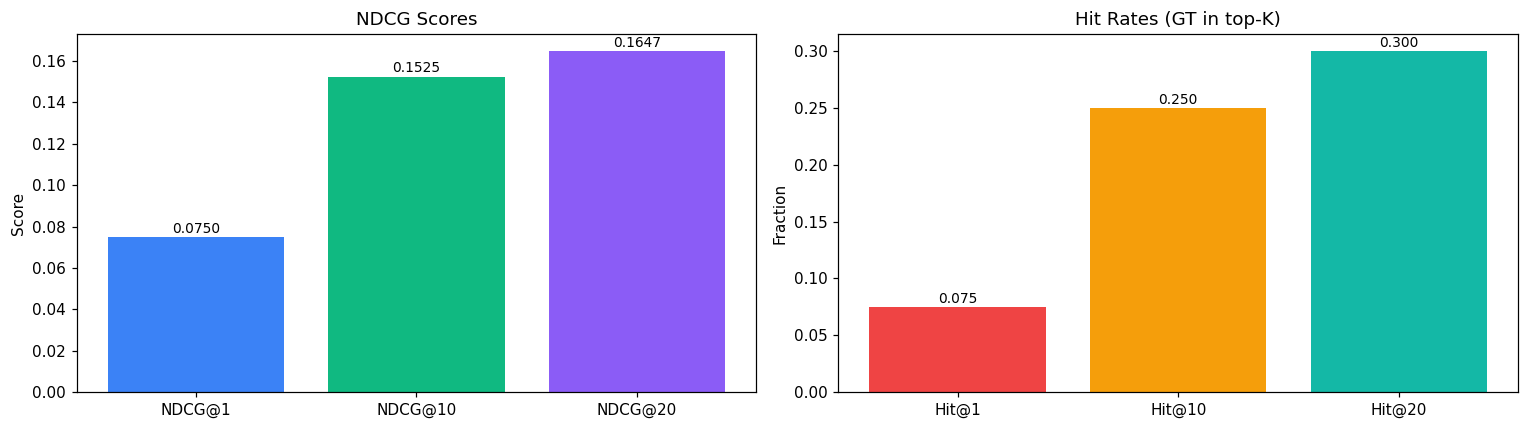

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ndcg_vals = [np.mean(ndcg1_l), np.mean(ndcg10_l), np.mean(ndcg20_l)]
bars = axes[0].bar(["NDCG@1", "NDCG@10", "NDCG@20"], ndcg_vals,
                   color=["#3b82f6", "#10b981", "#8b5cf6"])
axes[0].set_title("NDCG Scores")
axes[0].set_ylabel("Score")
for bar, v in zip(bars, ndcg_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f"{v:.4f}", ha="center", va="bottom", fontsize=9)

hit_vals = [np.mean(hit1_l), np.mean(hit10_l), np.mean(hit20_l)]
bars2 = axes[1].bar(["Hit@1", "Hit@10", "Hit@20"], hit_vals,
                    color=["#ef4444", "#f59e0b", "#14b8a6"])
axes[1].set_title("Hit Rates (GT in top-K)")
axes[1].set_ylabel("Fraction")
for bar, v in zip(bars2, hit_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

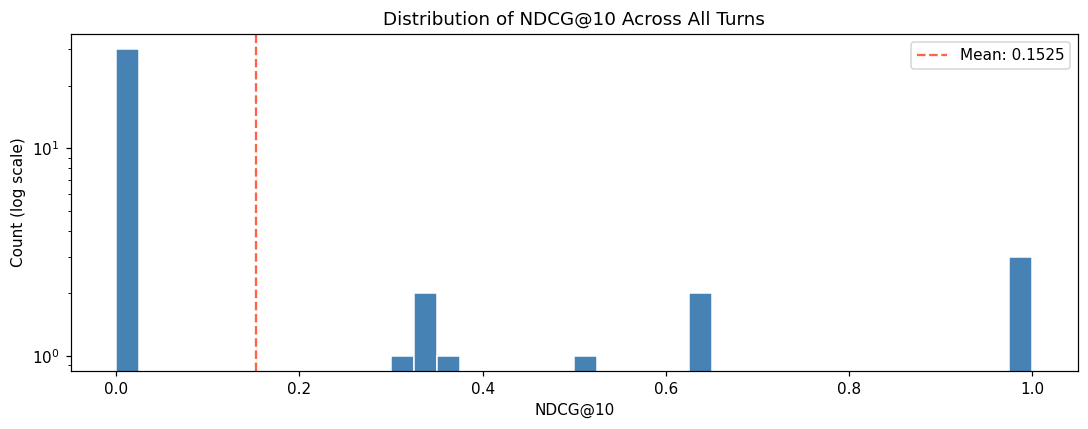

GT in top-20 for 30.0% of turns; missed in 70.0%.


In [9]:
plt.figure(figsize=(10, 4))
plt.hist(ndcg10_l, bins=40, color="steelblue", edgecolor="white")
plt.axvline(np.mean(ndcg10_l), color="tomato", linestyle="--",
            label=f"Mean: {np.mean(ndcg10_l):.4f}")
plt.title("Distribution of NDCG@10 Across All Turns")
plt.xlabel("NDCG@10")
plt.ylabel("Count (log scale)")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()
print(f"GT in top-20 for {np.mean(hit20_l):.1%} of turns; missed in {1-np.mean(hit20_l):.1%}.")

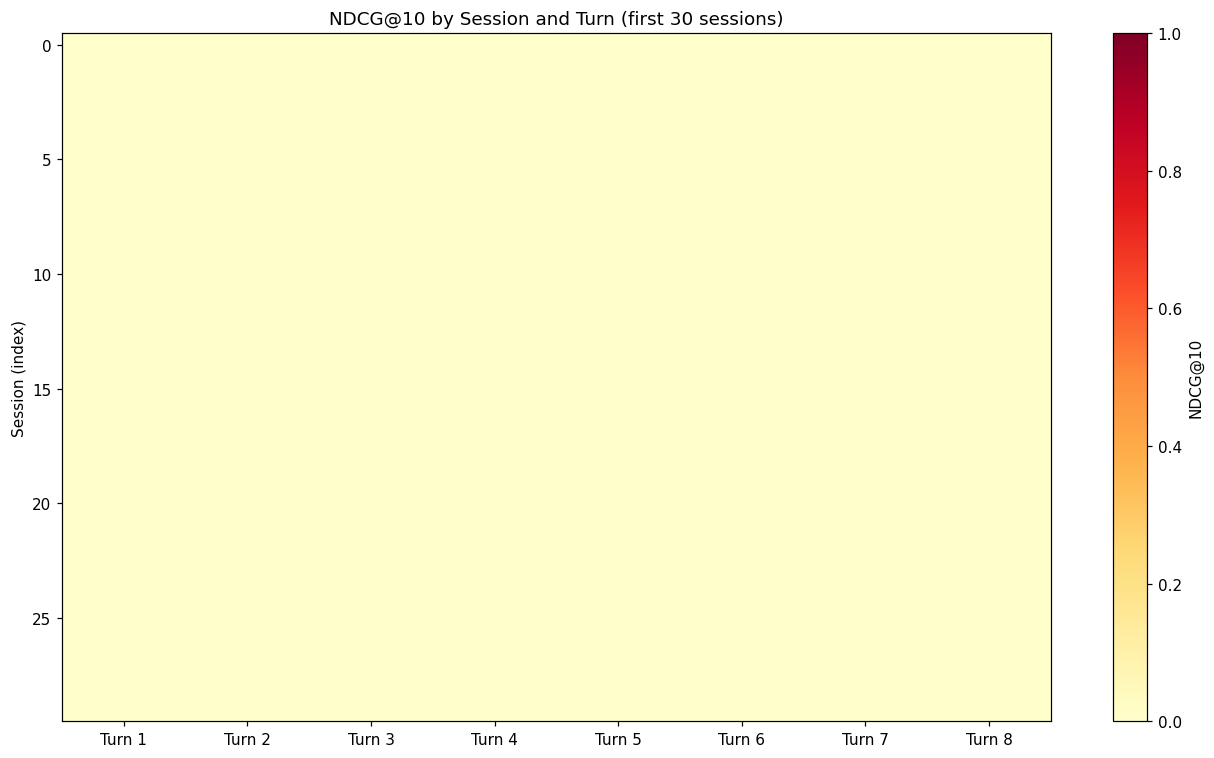

In [10]:
# Per-session heatmap (first 30 sessions)
session_ids = sorted(sessions_dict.keys())
N = min(30, len(session_ids))
ndcg_matrix = np.zeros((N, 8))
for i, sid in enumerate(session_ids[:N]):
    for t in range(1, 9):
        gt    = ground_truth.get((sid, t))
        ptids = predictions.get((sid, t), {}).get("predicted_track_ids", [])
        ndcg_matrix[i, t-1] = ndcg_at_k(ptids, gt, 10)

plt.figure(figsize=(12, 7))
im = plt.imshow(ndcg_matrix, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
plt.colorbar(im, label="NDCG@10")
plt.xticks(range(8), [f"Turn {i+1}" for i in range(8)])
plt.ylabel("Session (index)")
plt.title(f"NDCG@10 by Session and Turn (first {N} sessions)")
plt.tight_layout()
plt.show()

---
## Interactive Session Browser

Pick any session and turn to see: conversation, ground truth song, predicted tracks, and scores.

In [11]:
pred_sids = sorted({sid for (sid, _) in predictions if sid in sessions_dict})

session_dropdown = widgets.Dropdown(
    options=pred_sids,
    description="Session:",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="480px")
)
turn_slider = widgets.IntSlider(
    value=1, min=1, max=8, step=1,
    description="Turn:",
    style={"description_width": "40px"},
    layout=widgets.Layout(width="300px")
)

out_info    = widgets.Output()
out_conv    = widgets.Output()
out_metrics = widgets.Output()
out_gt      = widgets.Output()
out_preds   = widgets.Output()

def render(sid, turn):
    session = sessions_dict.get(sid, {})
    pred    = predictions.get((sid, turn), {})
    gt_id   = ground_truth.get((sid, turn))
    ptids   = pred.get("predicted_track_ids", [])
    response= pred.get("predicted_response", "")
    profile = session.get("user_profile", {})

    with out_info:
        clear_output(wait=True)
        display(HTML(
            f'<div style="border:1px solid rgba(99,102,241,0.3);border-left:4px solid #6366f1;'
            f'padding:10px;border-radius:8px;font-size:0.9em">'
            f'<b>Session:</b> {sid[:8]}...<br>'
            f'<b>User:</b> {profile.get("age_group","?")} {profile.get("gender","?")} from {profile.get("country_name","?")}<br>'
            f'<b>Culture:</b> {profile.get("preferred_musical_culture","?")}<br>'
            f'<b>Goal:</b> <i>{session.get("conversation_goal",{}).get("listener_goal","?")[:140]}...</i>'
            f'</div>'
        ))

    with out_conv:
        clear_output(wait=True)
        display(HTML(conversation_html(session, target_turn=turn)))

    with out_metrics:
        clear_output(wait=True)
        if gt_id and ptids:
            n1  = ndcg_at_k(ptids, gt_id, 1)
            n10 = ndcg_at_k(ptids, gt_id, 10)
            n20 = ndcg_at_k(ptids, gt_id, 20)
            h1  = hit_at_k(ptids, gt_id, 1)
            h10 = hit_at_k(ptids, gt_id, 10)
            h20 = hit_at_k(ptids, gt_id, 20)
            rank_note = f" · ground truth at rank {ptids.index(gt_id)+1}" if gt_id in ptids else " · not in top-20"
            display(HTML(
                f'<div style="background:rgba(34,197,94,0.1);border-left:3px solid #22c55e;'
                f'padding:10px;border-radius:0 8px 8px 0;font-size:0.9em">'
                f'<b>Turn {turn}{rank_note}</b><br>'
                f'NDCG@1={n1:.4f} &nbsp;|&nbsp; NDCG@10={n10:.4f} &nbsp;|&nbsp; NDCG@20={n20:.4f}<br>'
                f'Hit@1={h1} &nbsp;|&nbsp; Hit@10={h10} &nbsp;|&nbsp; Hit@20={h20}'
                f'</div>'
            ))
        elif not ptids:
            display(HTML("<i>No predictions for this turn.</i>"))
        else:
            display(HTML("<i>No ground truth for this turn.</i>"))

    with out_gt:
        clear_output(wait=True)
        if gt_id:
            rank_in = ptids.index(gt_id) + 1 if gt_id in ptids else None
            note = f"Found at rank {rank_in} ✅" if rank_in else "Not in top-20 ❌"
            display(HTML(f"<b>Ground Truth Song</b> — {note}<br>" + track_card_html(gt_id, highlight=True)))
        else:
            display(HTML("<i>No ground truth for this turn.</i>"))

    with out_preds:
        clear_output(wait=True)
        if ptids:
            cards = "".join(track_card_html(tid, rank=i+1, highlight=(tid == gt_id)) for i, tid in enumerate(ptids))
            display(HTML(f"<div style='overflow-x:auto'>{cards}</div>"))
            if response:
                display(HTML(
                    f'<div style="margin-top:10px;background:rgba(34,197,94,0.1);border-left:4px solid #22c55e;'
                    f'padding:10px;border-radius:0 8px 8px 0">'
                    f'<b>LLM Response:</b><br>{response}</div>'
                ))
        else:
            display(HTML("<i>No predictions loaded.</i>"))

def on_change(_):
    render(session_dropdown.value, turn_slider.value)

session_dropdown.observe(on_change, names="value")
turn_slider.observe(on_change, names="value")

left = widgets.VBox([
    widgets.HTML("<h4 style='margin:4px 0'>Session Info</h4>"), out_info,
    widgets.HTML("<h4 style='margin:4px 0'>Conversation</h4>"), out_conv,
], layout=widgets.Layout(width="44%", padding="0 8px 0 0"))

right = widgets.VBox([
    widgets.HTML("<h4 style='margin:4px 0'>Metrics</h4>"), out_metrics,
    widgets.HTML("<h4 style='margin:4px 0'>Ground Truth</h4>"), out_gt,
    widgets.HTML("<h4 style='margin:4px 0'>Top-20 Predicted Tracks</h4>"), out_preds,
], layout=widgets.Layout(width="56%"))

render(pred_sids[0], 1)
display(widgets.VBox([widgets.HBox([session_dropdown, turn_slider]), widgets.HBox([left, right])]))

---
## Compare Multiple Prediction Files

In [12]:
pred_files = sorted(glob.glob("../exp/inference/devset/*.json"))

if len(pred_files) > 1:
    rows = []
    for fp in pred_files:
        with open(fp) as f:
            local = {(p["session_id"], p["turn_number"]): p["predicted_track_ids"] for p in json.load(f)}
        unique_ids = {tid for ids in local.values() for tid in ids}
        pairs = [(sid, t) for sid in sessions_dict for t in range(1,9) if (sid,t) in local]
        rows.append({
            "File":  os.path.basename(fp),
            "NDCG@10": f"{np.mean([ndcg_at_k(local[k], ground_truth.get(k), 10) for k in pairs]):.4f}",
            "NDCG@20": f"{np.mean([ndcg_at_k(local[k], ground_truth.get(k), 20) for k in pairs]):.4f}",
            "Hit@20":  f"{np.mean([hit_at_k(local[k],  ground_truth.get(k), 20) for k in pairs]):.2%}",
            "Catalog Diversity": f"{len(unique_ids)/len(track_meta):.4f}",
        })
    display(pd.DataFrame(rows))
else:
    print(f"Only {len(pred_files)} file(s) found. Run more experiments to compare.")

Only 1 file(s) found. Run more experiments to compare.
